In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
def kpss_test(series, **kw):    
    statistic, p_value, n_lags, critical_values = kpss(series, **kw)
    # Format Output
    print(f'KPSS Statistic: {statistic}')
    print(f'p-value: {p_value}')
    print(f'num lags: {n_lags}')
    print('Critial Values:')
    for key, value in critical_values.items():
        print(f'   {key} : {value}')
    print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

In [3]:
lookback_window = 5

In [4]:
df = pd.read_csv('../datasets/processed/final_binned_sum_2_task_usage.csv')

df.head()

,time_bins,mean_CPU_usage_rate,canonical_memory_usage,assigned_memory_usage,unmapped_page_cache_memory_usage,total_page_cache_memory_usage,mean_disk_I/O_time,mean_local_disk_space_used,cycles_per_instruction,memory_accesses_per_instruction,sampled_CPU_usage,maximum_memory_usage,maximum_CPU_usage,maximum_disk_IO_time
0,1970-01-01 00:10:00,934.529654,1122.081556,1410.075742,137.780170,350.844039,86.576681,5.747562,232414.073578,760.927511,540.826122,0.752,1.861,1.070
1,1970-01-01 00:12:00,953.734497,1094.832993,1380.893418,137.186724,342.614090,90.112028,5.714715,233349.010286,763.722785,560.613661,0.752,1.861,1.070
2,1970-01-01 00:14:00,1069.803710,1137.664539,1430.936623,138.977231,343.964416,107.931067,5.800870,246048.623559,807.370802,673.262978,0.752,1.861,1.070
3,1970-01-01 00:16:00,949.991326,1099.295547,1386.312936,137.164647,341.334571,90.891698,5.745408,232222.657193,761.606960,548.807038,0.752,1.656,1.041
4,1970-01-01 00:18:00,962.463198,1106.237590,1395.191419,137.889897,342.393872,92.711914,5.766440,229743.424184,755.449583,563.318817,0.752,1.656,1.041


# **EDA**

In [5]:
num_df = df.select_dtypes(include="number") 
Q3 = num_df.quantile(0.75)
Q1 = num_df.quantile(0.25)

upper_bound = Q3 + 3*(Q3 - Q1) / 2
lower_bound = Q1 - 3*(Q3 - Q1) / 2

outliers = (num_df < lower_bound) | (num_df > upper_bound)

print(f"Outliers Percentage: {len(outliers.sum()) / len(df)}")

Outliers Percentage: 0.0006226053639846744


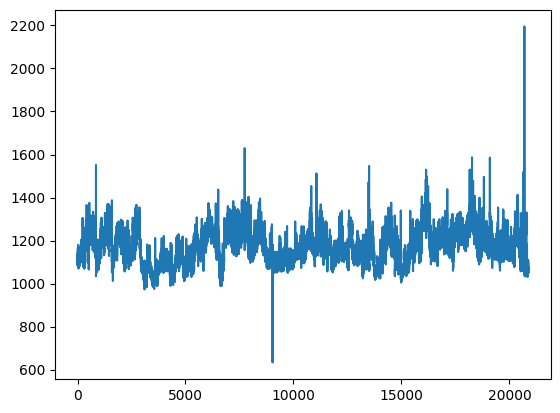

In [6]:
df['canonical_memory_usage'].plot.line()

plt.show()

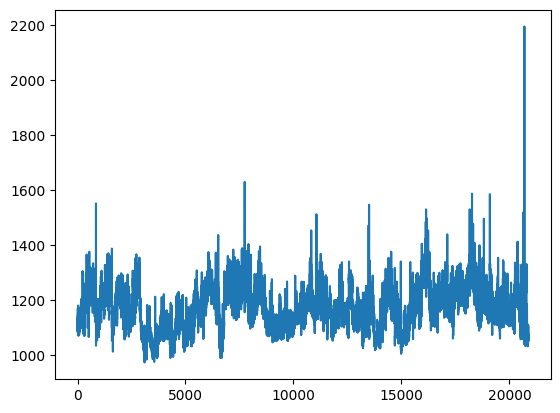

In [7]:
# Step 2: Replace Flagged canonical_memory_usages with NaN
df.loc[df['canonical_memory_usage'] < 900, 'canonical_memory_usage'] = np.nan

# Step 3: Interpolate the NaN canonical_memory_usages
df['canonical_memory_usage'] = df['canonical_memory_usage'].interpolate(method='cubicspline')

df['canonical_memory_usage'].plot.line()

plt.show()

In [8]:
# Calculate the sizes for each split
train_size = int(0.8 * len(df))
val_size = int(0.1 * len(df))
test_size = len(df) - train_size - val_size

# **Preprocessing**

In [9]:
# cpu_max = df['mean_CPU_usage_rate'][:train_size].max()
# memory_max = df['canonical_memory_usage'][:train_size].max()

cpu_max = 4000
memory_max = 3000

print(cpu_max, memory_max)

4000 3000


In [10]:
df['mean_CPU_usage_rate'] = df['mean_CPU_usage_rate'] / cpu_max
df['canonical_memory_usage'] = df['canonical_memory_usage'] / memory_max

# df['mean_CPU_usage_rate'] = df['mean_CPU_usage_rate'].clip(0, 1)
# df['canonical_memory_usage'] = df['canonical_memory_usage'].clip(0, 1)

ADF Statistic: -4.817838
p-value: 0.000050
KPSS Statistic: 5.800102938849421
p-value: 0.01
num lags: 87
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is not stationary


/tmp/ipykernel_282740/3001471310.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(series, **kw)


<Axes: >

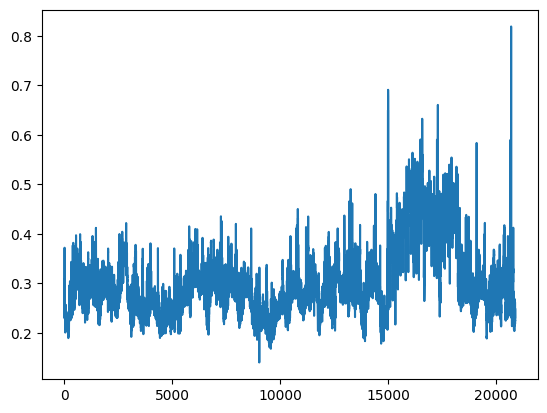

In [11]:
result = adfuller(df[['mean_CPU_usage_rate']].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

kpss_test(df['mean_CPU_usage_rate'])

df['mean_CPU_usage_rate'].plot.line()

ADF Statistic: -6.783861
p-value: 0.000000
KPSS Statistic: 1.4819466036855118
p-value: 0.01
num lags: 87
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is not stationary


/tmp/ipykernel_282740/3001471310.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(series, **kw)


<Axes: >

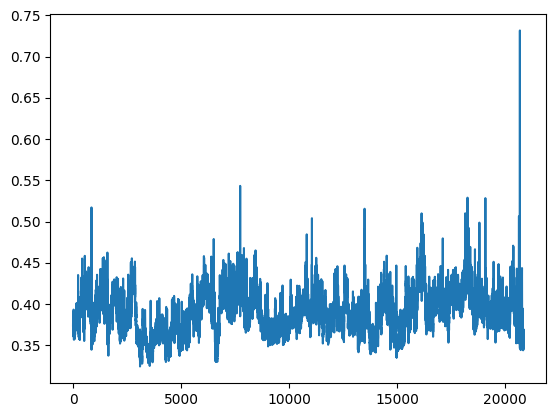

In [12]:
result = adfuller(df[['canonical_memory_usage']].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

kpss_test(df['canonical_memory_usage'])

df['canonical_memory_usage'].plot.line()

Dataset is not stationary

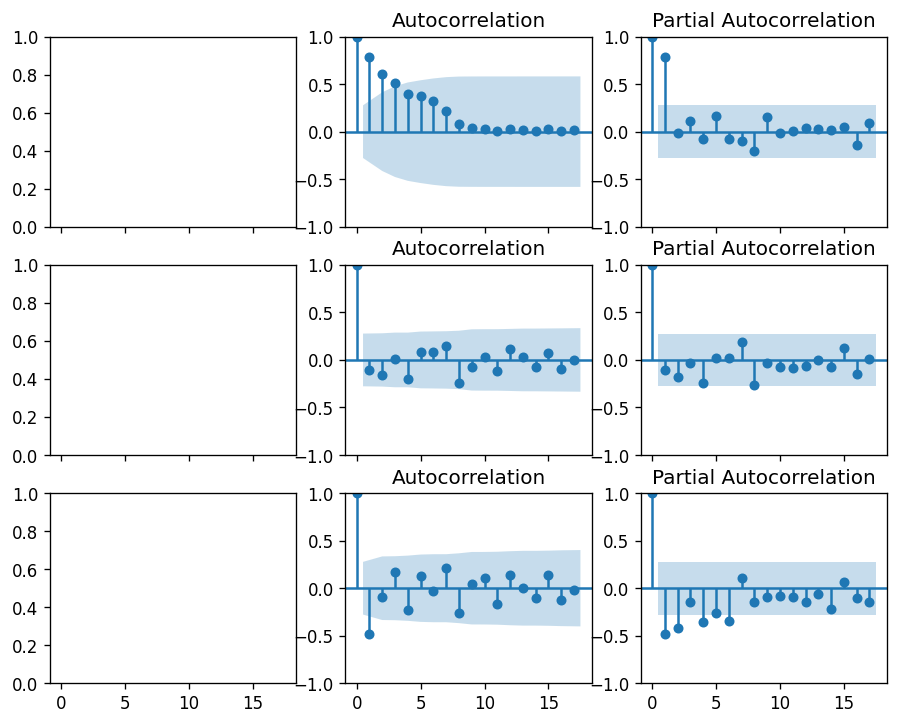

In [13]:
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})


# Original Series
fig, axes = plt.subplots(3, 3, sharex=True)
# axes[0, 0].plot(df['mean_CPU_usage_rate']); axes[0, 0].set_title('Original Series')
plot_acf(df['mean_CPU_usage_rate'][:50], ax=axes[0, 1])
plot_pacf(df['mean_CPU_usage_rate'][:50], ax=axes[0, 2])

# 1st Differencing
# axes[1, 0].plot(df['mean_CPU_usage_rate'].diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df['mean_CPU_usage_rate'].diff().dropna()[:50], ax=axes[1, 1])
plot_pacf(df['mean_CPU_usage_rate'].diff().dropna()[:50], ax=axes[1, 2])

# 2nd Differencing
# axes[2, 0].plot(df['mean_CPU_usage_rate'].diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df['mean_CPU_usage_rate'].diff().diff().dropna()[:50], ax=axes[2, 1])
plot_pacf(df['mean_CPU_usage_rate'].diff().diff().dropna()[:50], ax=axes[2, 2])

plt.show()

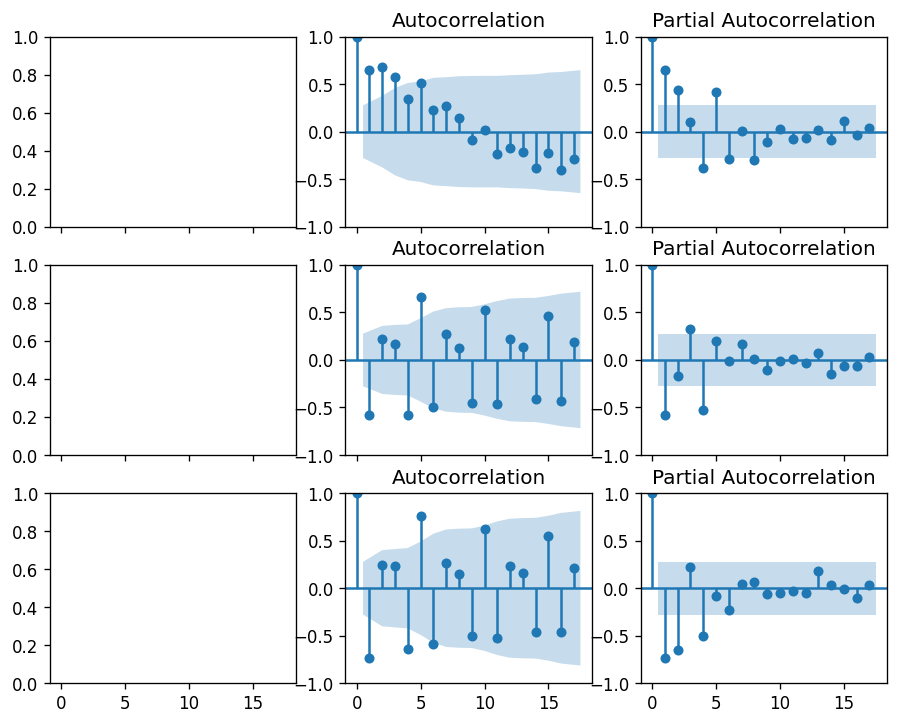

In [14]:
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})


# Original Series
fig, axes = plt.subplots(3, 3, sharex=True)
# axes[0, 0].plot(df['canonical_memory_usage']); axes[0, 0].set_title('Original Series')
plot_acf(df['canonical_memory_usage'][:50], ax=axes[0, 1])
plot_pacf(df['canonical_memory_usage'][:50], ax=axes[0, 2])

# 1st Differencing
# axes[1, 0].plot(df['canonical_memory_usage'].diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df['canonical_memory_usage'].diff().dropna()[:50], ax=axes[1, 1])
plot_pacf(df['canonical_memory_usage'].diff().dropna()[:50], ax=axes[1, 2])

# 2nd Differencing
# axes[2, 0].plot(df['canonical_memory_usage'].diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df['canonical_memory_usage'].diff().diff().dropna()[:50], ax=axes[2, 1])
plot_pacf(df['canonical_memory_usage'].diff().diff().dropna()[:50], ax=axes[2, 2])

plt.show()

# **Modeling**

In [15]:
import pmdarima as pm
cpu_model = pm.auto_arima(df['mean_CPU_usage_rate'], 
                        start_p=1, start_q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)
print(cpu_model.summary())


/home/kirantiloh/.pyenv/versions/ds-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kirantiloh/.pyenv/versions/ds-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kirantiloh/.pyenv/versions/ds-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kirantiloh/.pyenv/versions/ds-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kirantiloh/.pyenv/versions/ds-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: F

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-106424.820, Time=2.90 sec


/home/kirantiloh/.pyenv/versions/ds-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,0)(0,0,0)[0]             : AIC=9979.956, Time=0.77 sec


/home/kirantiloh/.pyenv/versions/ds-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(3,0,3)(0,0,0)[0]             : AIC=-109299.155, Time=14.07 sec


/home/kirantiloh/.pyenv/versions/ds-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-106767.393, Time=13.62 sec


/home/kirantiloh/.pyenv/versions/ds-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=-109283.316, Time=73.59 sec

Best model:  ARIMA(3,0,3)(0,0,0)[0]          
Total fit time: 149.056 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                20880
Model:               SARIMAX(3, 0, 3)   Log Likelihood               54656.577
Date:                Sat, 31 May 2025   AIC                        -109299.155
Time:                        15:52:13   BIC                        -109243.529
Sample:                             0   HQIC                       -109280.994
                              - 20880                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5142      0.004   -122.906      0.000      -

In [16]:
ram_model = pm.auto_arima(df['canonical_memory_usage'], 
                        start_p=1, start_q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=4, max_q=34 # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)
print(ram_model.summary())


SyntaxError: invalid syntax. Perhaps you forgot a comma? (748777050.py, line 4)

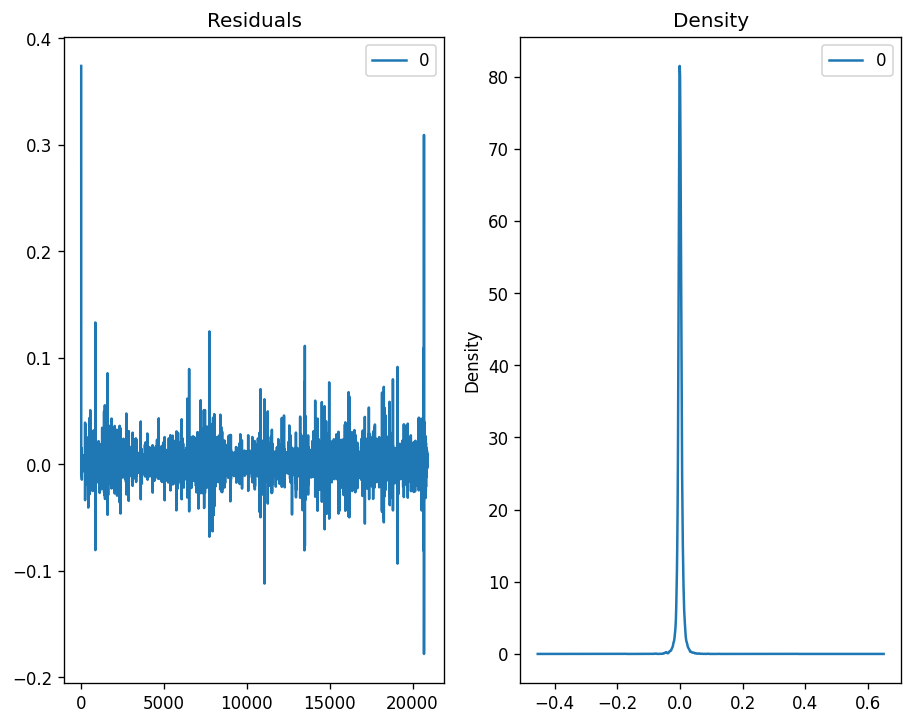

In [ ]:
residuals = pd.DataFrame(ram_model_fit.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

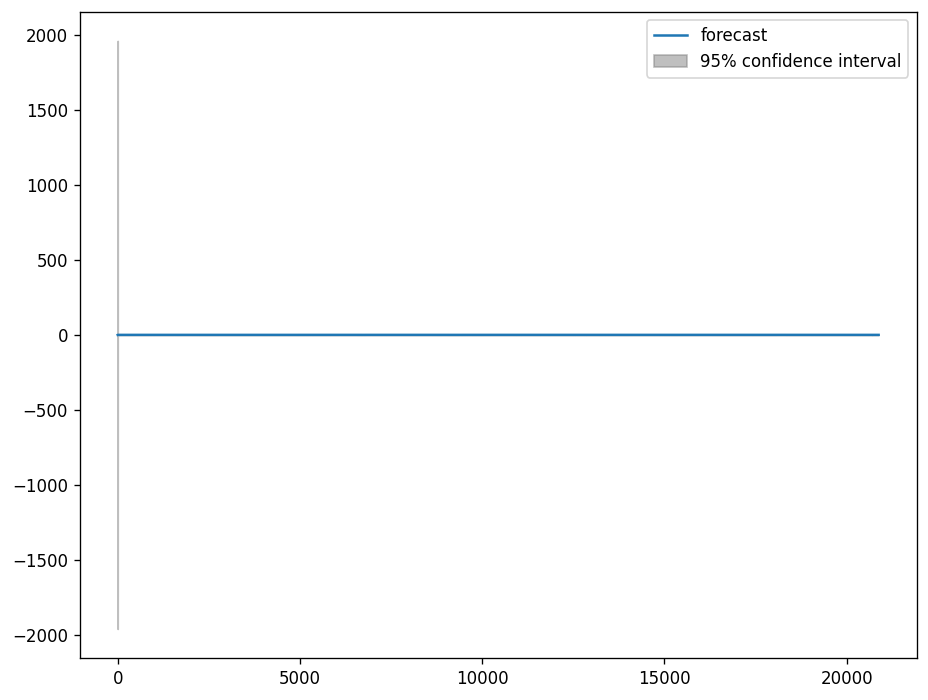

In [ ]:
from statsmodels.graphics.tsaplots import plot_predict

plot_predict(ram_model_fit)
plt.show()